In [1]:
from pathlib import Path
from readers import RawImage, RawSpecim
import matplotlib.pyplot as plt
import numpy as np
import math
from tqdm import tqdm
from scipy.interpolate import interp1d
import seaborn as sns
from pathlib import Path
import cv2
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import spectral.io.envi as envi

sns.set_theme('notebook')


In [2]:
base_path = Path("./data/flashlight")

Загружаем данные, делаем нормализацию картинок

In [3]:
def load_and_decode(phone_noflash_path, phone_flash_path, specim_dir):
    p_noflash = Path(phone_noflash_path)
    p_flash = Path(phone_flash_path)
    p_specim = Path(specim_dir)

    raw_noflash = RawImage.from_file(p_noflash)
    img_noflash_norm = raw_noflash.get_exposure_normalized_img(exposure=True, iso=True)

    raw_flash = RawImage.from_file(p_flash)
    img_flash_norm = raw_flash.get_exposure_normalized_img(exposure=True, iso=True)

    raw_specim = RawSpecim.from_directory(p_specim)
    img_specim_norm = raw_specim.get_exposure_normalized_img()

    scene_data = {
        "noflash": img_noflash_norm,
        "flash": img_flash_norm,
        "specim": img_specim_norm,
        "wavelengths": raw_specim.wavelengths
    }

    return scene_data

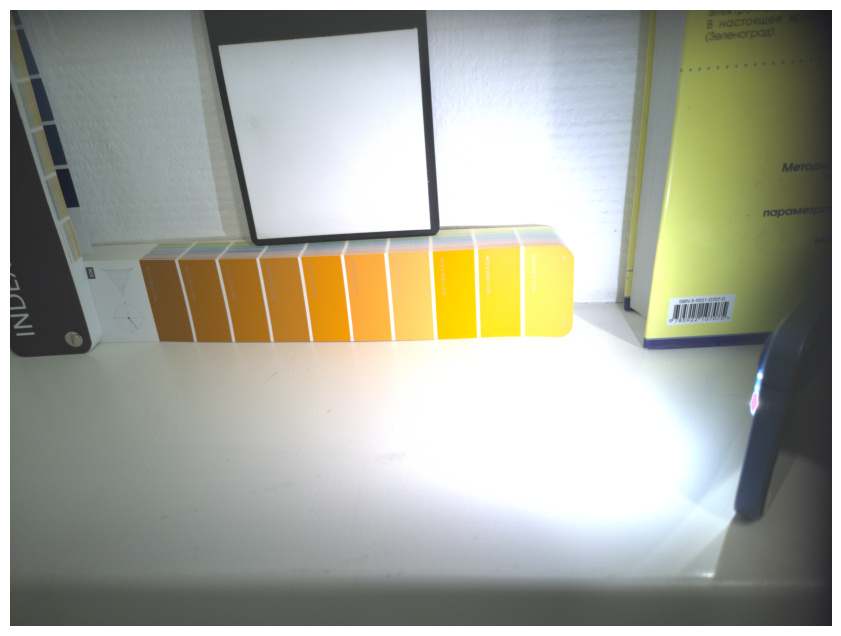

In [4]:
def visualize_raw_image(raw_obj: RawImage, brightness=1.0):
    img = raw_obj._img_int / (raw_obj.white_level_per_channel.astype(np.float32) + 1e-6)

    h, w, c = img.shape
    img = img.reshape(-1, 3)
    img_srgb = (img @ raw_obj.rgb2srgb.T).reshape(h, w, 3)

    img_srgb = np.clip(img_srgb * brightness, 0, 1)
    img_final = np.power(img_srgb, 1.0/2.2)

    img_final = np.flip(img_final, axis=1)
    img_final = np.flip(img_final, axis=0)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_final)
    # plt.title(f"Processed DNG: {raw_obj.exposure_time}s, ISO {raw_obj.iso}")
    plt.axis('off')
    plt.show()

raw_data = RawImage.from_file("data/flashlight/2_flash.dng")
visualize_raw_image(raw_data, brightness=1.5)

In [4]:
def visualize_all_dngs(directory="data/flashlight", cols=3):
    path = Path(directory)
    dng_files = sorted(list(path.glob("*.dng")),
                       key=lambda x: int(x.stem) if x.stem.isdigit() else 999)

    num_files = len(dng_files)
    rows = math.ceil(num_files / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
    axes = axes.flatten()

    print(f"Найденно {num_files} dng файлов...")

    for i, file_path in enumerate(dng_files):
        raw_obj = RawImage.from_file(file_path)

        img = raw_obj._img_int / (raw_obj.white_level_per_channel.astype(np.float32) + 1e-6)
        img_final = np.clip(img, 0, 1)

        img_final = np.flip(img_final, axis=1)
        img_final = np.flip(img_final, axis=0)

        axes[i].imshow(img_final)
        axes[i].set_title(f"Файл: {file_path.name}\nExp: {raw_obj.exposure_time}s | ISO: {raw_obj.iso}")

        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
visualize_all_dngs(directory="data/flashlight")

In [4]:
def interpolate_specim(specim_obj, start_wl=400, end_wl=700, num_bands=31):
    """
    Интерполирует в заданный диапазон
    """
    target_wavelengths = np.linspace(start_wl, end_wl, num_bands)

    interpolator = interp1d(
        specim_obj.wavelengths,
        specim_obj._img_int,
        axis=-1,
        kind='linear',
        bounds_error=False,
        fill_value='extrapolate'
    )

    resampled_cube = interpolator(target_wavelengths)

    resampled_cube = np.clip(resampled_cube, 0, None)

    return resampled_cube, target_wavelengths

def interpolate_cube_to_31(cube_raw, specim_wls):
    target_wls = np.linspace(400, 700, 31)

    H, W, C = cube_raw.shape
    flat_cube = cube_raw.reshape(-1, C)

    interp_func = interp1d(specim_wls, flat_cube, axis=1, kind='linear', fill_value="extrapolate")
    flat_cube_31 = interp_func(target_wls)

    cube_31 = flat_cube_31.reshape(H, W, len(target_wls))

    return cube_31, target_wls

def get_approx_rgb(cube, wavelengths):
    """
    Собирает false RGB изображение (просто выбираем похожие длины волн)
    """
    r_idx = np.argmin(np.abs(wavelengths - 650.0))
    g_idx = np.argmin(np.abs(wavelengths - 550.0))
    b_idx = np.argmin(np.abs(wavelengths - 450.0))

    rgb_img = cube[:, :, [r_idx, g_idx, b_idx]].astype(np.float32)

    for i in range(3):
        ch = rgb_img[:, :, i]
        p_low, p_high = np.percentile(ch, 1), np.percentile(ch, 99)
        ch = np.clip((ch - p_low) / (p_high - p_low + 1e-6), 0, 1)
        rgb_img[:, :, i] = ch

    return rgb_img

def visualize_all_specim_cubes(base_dir="."):
    """
    Находит все папки Specim, обрабатывает и выводит сеткой.
    """
    base_path = Path(base_dir)

    specim_dirs = sorted([d for d in base_path.iterdir() if d.is_dir() and d.name.startswith("08")])

    cols = 3
    rows = math.ceil(len(specim_dirs) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()

    print(f"Найдено {len(specim_dirs)} Specim")

    for i, specim_dir in enumerate(specim_dirs):
        raw_specim = RawSpecim.from_directory(specim_dir)

        cube_31, wls_31 = interpolate_specim(raw_specim)

        approx_rgb = get_approx_rgb(cube_31, wls_31)

        axes[i].imshow(approx_rgb)
        axes[i].set_title(f"Сцена: {specim_dir.name}\nРазмер: {cube_31.shape}")


        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [5]:
def load_reflectance_from_results(directory_path):
    """
    Загружает Reflectance из папки results.
    """
    dir_path = Path(directory_path)
    scene_name = dir_path.name

    hdr_path = dir_path / "results" / f"REFLECTANCE_{scene_name}.hdr"

    img = envi.open(str(hdr_path))

    reflectance_cube = img.load()

    wls = np.array([float(w) for w in img.metadata['wavelength']])

    reflectance_cube = np.rot90(reflectance_cube, k=-1).copy()

    return reflectance_cube, wls

In [ ]:
def visualize_all_specim_cubes_from_results(base_path):
    specim_dirs = sorted([d for d in base_path.iterdir() if d.is_dir() and d.name.startswith("08")])

    cols = 3
    rows = math.ceil(len(specim_dirs) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

    if rows * cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    print(f"Найдено {len(specim_dirs)} сцен Specim")

    for i, specim_dir in enumerate(specim_dirs):
        cube_raw, specim_wls = load_reflectance_from_results(specim_dir)
        cube_31, wls_31 = interpolate_cube_to_31(cube_raw, specim_wls)

        approx_rgb = get_approx_rgb(cube_31, wls_31)

        axes[i].imshow(approx_rgb)
        axes[i].set_title(f"Сцена: {specim_dir.name}\nРазмер: {cube_31.shape}")
        axes[i].axis('off')

    for j in range(len(specim_dirs), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

Найдено 6 сцен Specim


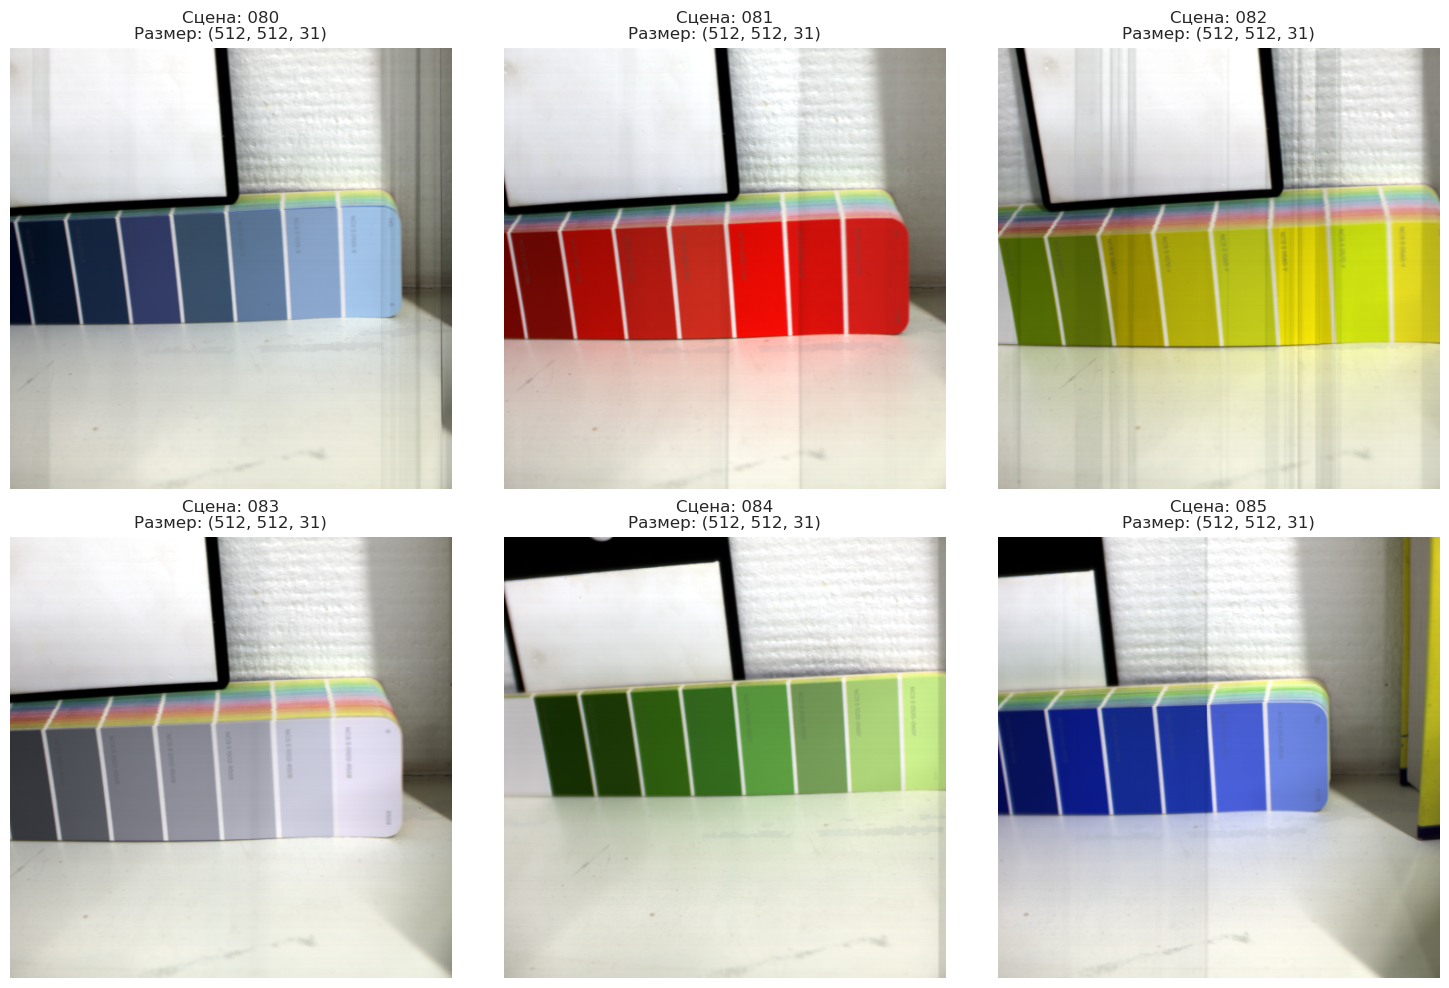

In [19]:
visualize_all_specim_cubes_from_results(base_path)

Найдено 6 Specim


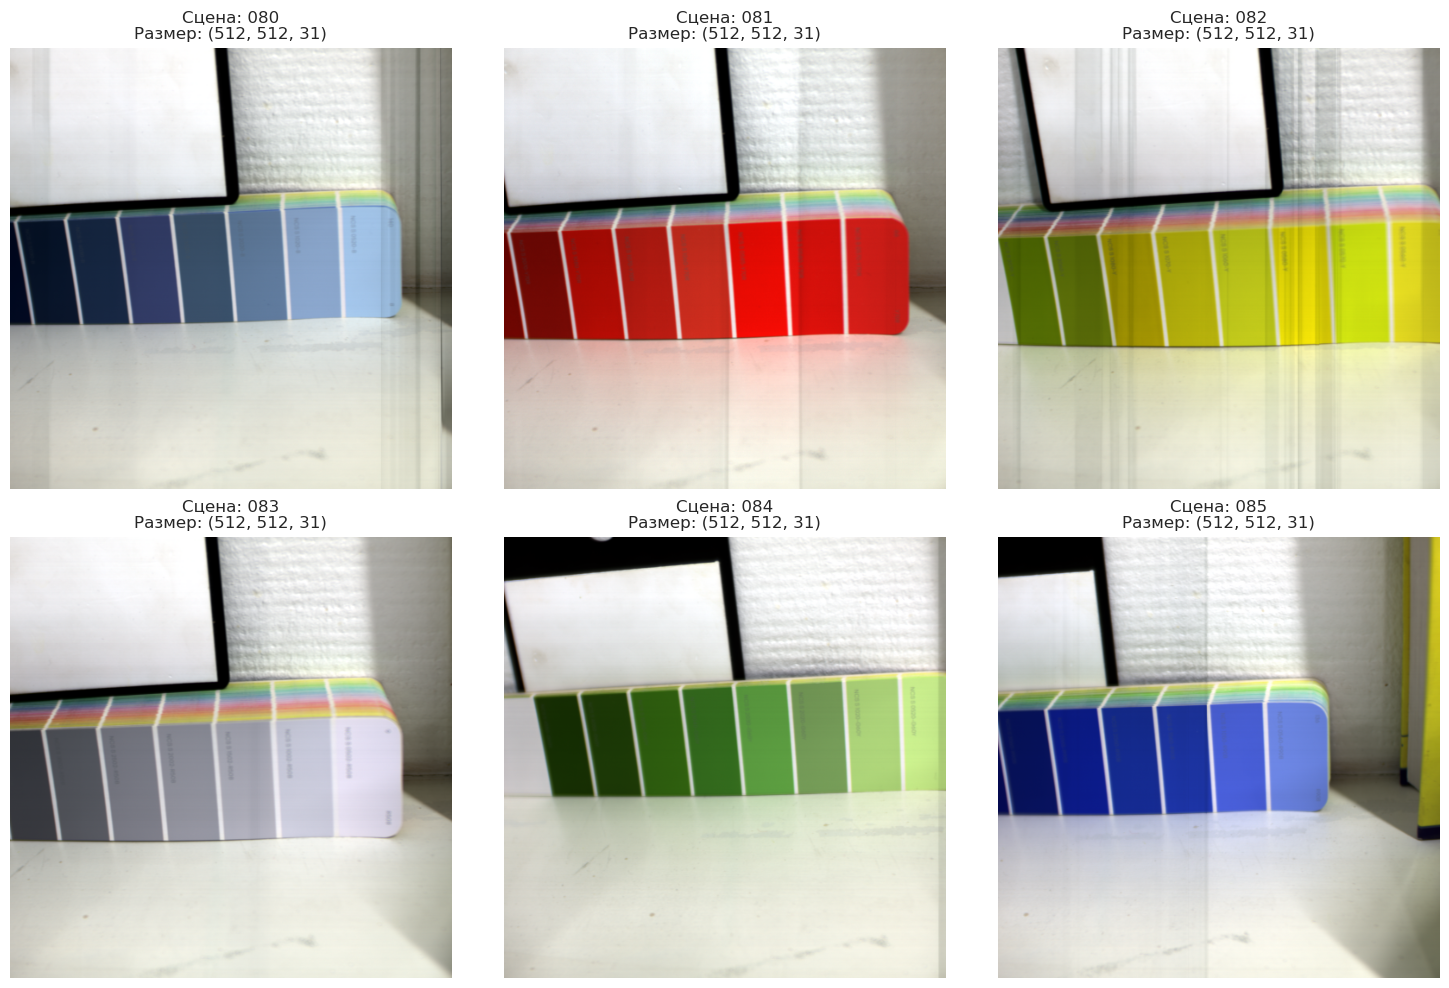

In [20]:
visualize_all_specim_cubes(base_dir="./data/flashlight")

In [6]:
def get_srgb_image(raw_obj: RawImage, brightness=1.5):
    """
    Преобразует сырые данные DNG в sRGB массив (0-1) для OpenCV/выравнивания.
    """
    img = raw_obj._img_int / (raw_obj.white_level_per_channel.astype(np.float32) + 1e-6)

    h, w, c = img.shape
    img_flat = img.reshape(-1, 3)
    img_srgb = (img_flat @ raw_obj.rgb2srgb.T).reshape(h, w, 3)

    img_srgb = np.clip(img_srgb * brightness, 0, 1)
    img_final = np.power(img_srgb, 1.0/2.2)

    img_final = np.flip(img_final, axis=1)
    img_final = np.flip(img_final, axis=0)
    return img_final

In [7]:
def get_image(raw_obj: RawImage,  brightness=1.5):
    img = raw_obj._img_int / (raw_obj.white_level_per_channel.astype(np.float32) + 1e-6)

    img_final = np.clip(img * brightness, 0, 1)

    img_final = np.flip(img_final, axis=1)
    img_final = np.flip(img_final, axis=0)

    return img_final

In [8]:
def load_ready_reflectance(directory_path, base_name="085"):
    """
    Загружает уже откалиброванный куб Reflectance из папки results.
    """
    # Путь к заголовочному файлу в папке results
    hdr_path = Path(directory_path) / "results" / f"REFLECTANCE_{base_name}.hdr"

    img = envi.open(str(hdr_path))

    reflectance_cube = img.load()

    wls = np.array([float(w) for w in img.metadata['wavelength']])

    print(f"Куб загружен! Размер: {reflectance_cube.shape}")
    print(f"Диапазон длин волн: {wls[0]} - {wls[-1]} нм")

    return reflectance_cube, wls

In [ ]:
def to_uint8(img):
    """Вспомогательная функция: перевод float [0..1] в uint8 [0..255] для OpenCV"""
    return (np.clip(img, 0, 1) * 255).astype(np.uint8)

def compute_homography(src_img, dst_img):
    """
    Находит матрицу трансформации (Homography) от src_img к dst_img с помощью SIFT.
    """
    src_gray = cv2.cvtColor(to_uint8(src_img), cv2.COLOR_RGB2GRAY)
    dst_gray = cv2.cvtColor(to_uint8(dst_img), cv2.COLOR_RGB2GRAY)

    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(src_gray, None)
    kp2, des2 = sift.detectAndCompute(dst_gray, None)

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    print(f"Найдено хороших точек: {len(good_matches)}")

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    return H

def align_pipeline(img_noflash_srgb, img_flash_srgb, img_noflash, img_flash, img_specim):
    """
    Выполняет полный пайплайн выравнивания:
    1. Flash -> NoFlash
    2. NoFlash -> Specim
    3. Применяет трансформации.
    """
    h_specim, w_specim = img_specim.shape[:2]

    print("--- Шаг 1: Ищем связь Flash -> NoFlash ---")
    H_flash_to_noflash = compute_homography(img_flash_srgb, img_noflash_srgb)

    print("--- Шаг 2: Ищем связь NoFlash -> Specim ---")
    H_noflash_to_specim = compute_homography(img_noflash_srgb, img_specim)

    print("--- Шаг 3: Математика матриц и искажение ---")
    # Перемножаем матрицы, чтобы получить прямую связь Flash -> Specim
    # Важно: порядок умножения H2 @ H1
    H_flash_to_specim = H_noflash_to_specim @ H_flash_to_noflash

    # Искажаем изображения под размер и ракурс Specim
    aligned_noflash_srgb = cv2.warpPerspective(img_noflash_srgb, H_noflash_to_specim, (w_specim, h_specim))
    aligned_flash_srgb = cv2.warpPerspective(img_flash_srgb, H_flash_to_specim, (w_specim, h_specim))
    aligned_noflash = cv2.warpPerspective(img_noflash, H_noflash_to_specim, (w_specim, h_specim))
    aligned_flash = cv2.warpPerspective(img_flash, H_flash_to_specim, (w_specim, h_specim))

    return aligned_noflash_srgb, aligned_flash_srgb, aligned_noflash, aligned_flash

raw_noflash = RawImage.from_file(Path("data/flashlight/6.dng"))
raw_flash = RawImage.from_file(Path("data/flashlight/6_flash.dng"))

img_noflash_srgb = get_srgb_image(raw_noflash)
img_flash_srgb = get_srgb_image(raw_flash)

img_noflash = get_image(raw_noflash)
img_flash = get_image(raw_flash)

# cube_204, specim_wls = load_ready_reflectance("085", "085")
# cube_31, wls_31 = interpolate_cube_to_31(cube_204, specim_wls)

specim_obj = RawSpecim.from_directory("data/flashlight/085")
cube_31, wls_31 = interpolate_specim(specim_obj)

img_specim = get_approx_rgb(cube_31, wls_31)

aligned_noflash_srgb, aligned_flash_srgb, aligned_noflash, aligned_flash = align_pipeline(img_noflash_srgb, img_flash_srgb, img_noflash, img_flash, img_specim)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

overlay_1 = cv2.addWeighted(to_uint8(aligned_noflash), 0.5, to_uint8(img_specim), 0.5, 0)
axes[0].imshow(overlay_1)
axes[0].set_title("NoFlash + Specim")

overlay_2 = cv2.addWeighted(to_uint8(aligned_flash), 0.5, to_uint8(img_specim), 0.5, 0)
axes[1].imshow(overlay_2)
axes[1].set_title("Flash + Specim (Слияние)")

overlay_3 = cv2.addWeighted(to_uint8(aligned_flash), 0.5, to_uint8(aligned_noflash), 0.5, 0)
axes[2].imshow(overlay_3)
axes[2].set_title("Flash + NoFlash (Слияние)")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

Найдено прямоугольников: 4


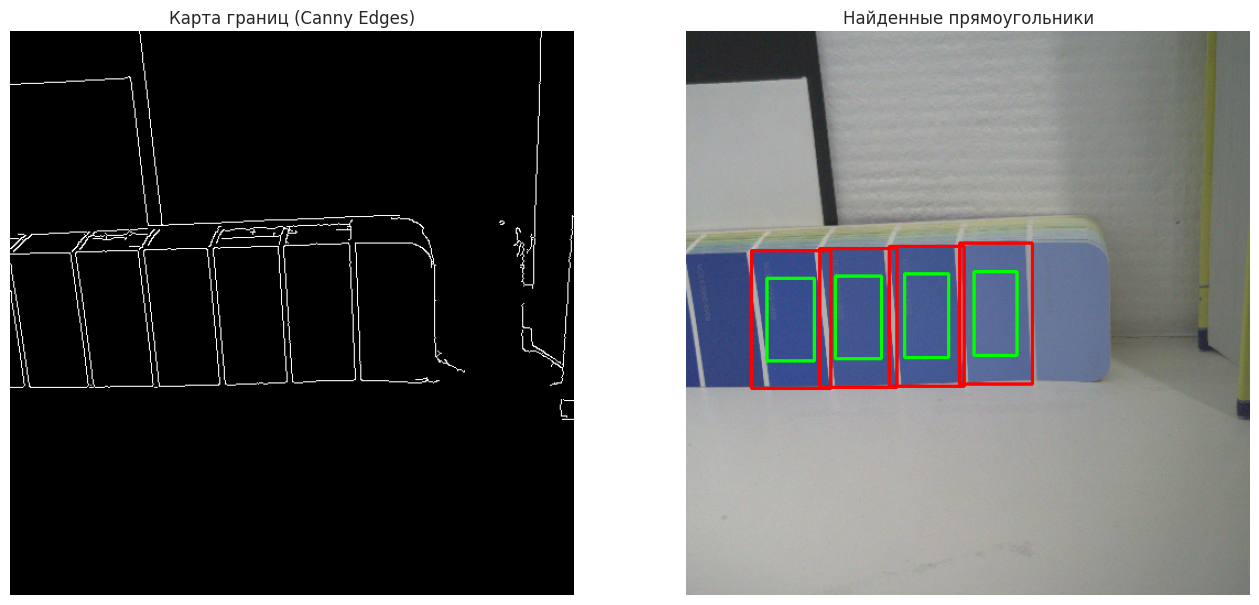

In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_and_shrink_rectangles(image, shrink_factor=0.8, min_area=500, max_area=50000, canny_thresh1=30, canny_thresh2=100):
    """
    Находит прямоугольники на изображении с повышенной чувствительностью к деталям.
    """
    if image.dtype == np.float32 or image.dtype == np.float64:
        img_uint8 = (np.clip(image, 0, 1) * 255).astype(np.uint8)
    else:
        img_uint8 = image.copy()

    result_img = img_uint8.copy()

    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)

    edges = cv2.Canny(blurred, canny_thresh1, canny_thresh2)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []

    for cnt in contours:
        area = cv2.contourArea(cnt)

        if min_area < area < max_area:
            x, y, w, h = cv2.boundingRect(cnt)

            new_w = int(w * shrink_factor)
            new_h = int(h * shrink_factor)

            cx = x + w / 2.0
            cy = y + h / 2.0

            new_x = int(cx - new_w / 2.0)
            new_y = int(cy - new_h / 2.0)

            boxes.append((new_x, new_y, new_w, new_h))

            cv2.rectangle(result_img, (x, y), (x + w, y + h), (255, 0, 0), 2)
            cv2.rectangle(result_img, (new_x, new_y), (new_x + new_w, new_y + new_h), (0, 255, 0), 2)

    return result_img, edges, boxes

drawn_img, edges_img, extracted_boxes = find_and_shrink_rectangles(
    aligned_noflash_srgb,
    shrink_factor=0.6,
    min_area=1000,
    max_area=30000,
    canny_thresh1=10,
    canny_thresh2=100
)

print(f"Найдено прямоугольников: {len(extracted_boxes)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# То, как алгоритм видит границы
axes[0].imshow(edges_img, cmap='gray')
axes[0].set_title("Карта границ (Canny Edges)")
axes[0].axis('off')

# Итоговый результат
axes[1].imshow(drawn_img)
axes[1].set_title("Найденные прямоугольники")
axes[1].axis('off')

plt.show()

In [45]:
def extract_dataset(img_noflash, img_flash, cube_specim, wavelengths, boxes):
    """
    Вырезает патчи по координатам рамок, усредняет цвета и собирает датасет.

    Parameters:
    -----------
    img_noflash : np.ndarray (H, W, 3) - выровненное фото без вспышки
    img_flash   : np.ndarray (H, W, 3) - выровненное фото со вспышкой
    cube_specim : np.ndarray (H, W, 31) - спектральный куб (тоже выровненный!)
    wavelengths : np.ndarray (31,) - длины волн для названий колонок
    boxes       : list - список координат (x, y, w, h)

    Returns:
    --------
    df : pd.DataFrame - готовый датасет
    """
    data_rows = []

    for i, (x, y, w, h) in enumerate(boxes):
        patch_no = img_noflash[y:y+h, x:x+w]
        patch_fl = img_flash[y:y+h, x:x+w]
        patch_sp = cube_specim[y:y+h, x:x+w]

        mean_no = np.mean(patch_no, axis=(0, 1))
        mean_fl = np.mean(patch_fl, axis=(0, 1))
        mean_sp = np.mean(patch_sp, axis=(0, 1))

        row = np.concatenate([mean_no, mean_fl, mean_sp])
        data_rows.append(row)

    cols_no = ['R', 'G', 'B']
    cols_fl = ['R_flash', 'G_flash', 'B_flash']
    cols_sp = [f'{int(wl)}' for wl in wavelengths]

    all_columns = cols_no + cols_fl + cols_sp

    df = pd.DataFrame(data_rows, columns=all_columns)

    return df

dataset_df = extract_dataset(
    img_noflash=aligned_noflash,
    img_flash=aligned_flash,
    cube_specim=cube_31,
    wavelengths=wls_31,
    boxes=extracted_boxes
)

print(f"Собрано образцов (строк): {len(dataset_df)}")
print(f"Количество признаков (колонок): {len(dataset_df.columns)}")

# Посмотрим на первые 5 строк
display(dataset_df.head())

# Сохраняем в CSV
dataset_df.to_csv("scene_01_dataset.csv", index=False)
print("\nДатасет успешно сохранен в 'scene_01_dataset.csv'!")

Собрано образцов (строк): 4
Количество признаков (колонок): 37


,R,G,B,R_flash,G_flash,B_flash,400,410,420,430,...,610,620,630,640,650,660,670,680,690,700
0,0.020419,0.087671,0.065231,0.040443,0.215866,0.200187,23.485310,27.298557,50.661593,148.792245,...,175.275883,152.620069,129.951604,108.895575,90.007204,73.088046,58.027835,48.069714,40.070350,34.096969
1,0.026310,0.103447,0.066971,0.067438,0.320282,0.261014,26.436596,31.282180,60.832513,179.342239,...,248.272179,211.845828,177.283988,147.046568,121.326022,98.345429,77.294782,62.328525,50.261245,41.430983
2,0.028746,0.114207,0.070636,0.100096,0.474812,0.373991,27.629404,33.038725,66.225768,198.117784,...,286.457028,246.689214,209.395635,175.622400,145.304180,116.443737,90.230561,71.382325,56.670600,46.243114
3,0.044716,0.157806,0.081540,0.214020,0.859958,0.570973,32.798920,40.448831,87.214163,268.077968,...,552.889521,478.891244,412.919111,354.112211,293.665010,228.747021,171.012011,128.109888,96.467281,75.635585



Датасет успешно сохранен в 'scene_01_dataset.csv'!


Матрица чувствительности (31, 3)


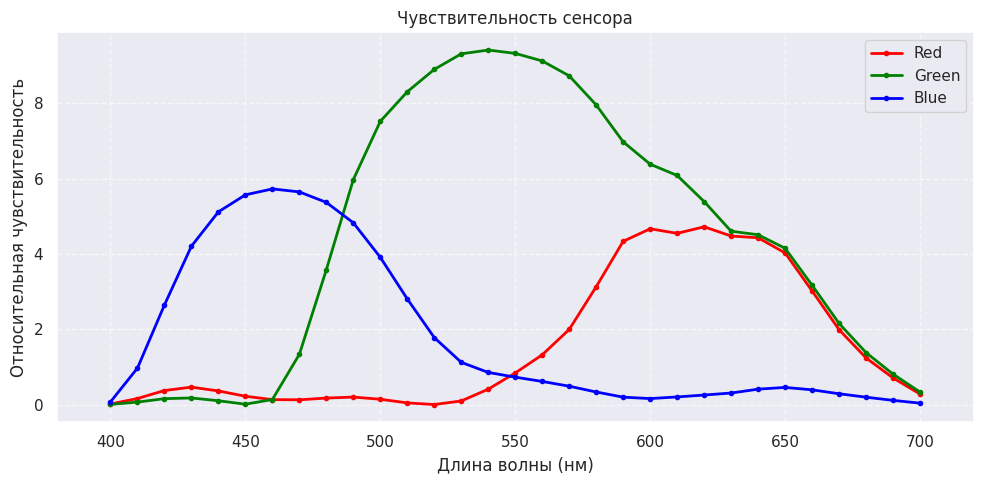

In [46]:
csv_path = "sensitivities-main.csv"
df_cam = pd.read_csv(csv_path)

df_cam.columns = df_cam.columns.str.lower()

cam_wls = df_cam['wavelength'].values
cam_r = df_cam['r'].values
cam_g = df_cam['g'].values
cam_b = df_cam['b'].values

target_wls = np.linspace(400, 700, 31)

interp_r = interp1d(cam_wls, cam_r, kind='linear', bounds_error=False, fill_value=0)
interp_g = interp1d(cam_wls, cam_g, kind='linear', bounds_error=False, fill_value=0)
interp_b = interp1d(cam_wls, cam_b, kind='linear', bounds_error=False, fill_value=0)

sens_r_31 = interp_r(target_wls)
sens_g_31 = interp_g(target_wls)
sens_b_31 = interp_b(target_wls)

camera_sensor = np.column_stack((sens_r_31, sens_g_31, sens_b_31))

camera_sensitivity_matrix = np.clip(camera_sensor, 0, None)

print(f"Матрица чувствительности {camera_sensor.shape}")

plt.figure(figsize=(10, 5))
plt.plot(target_wls, camera_sensor[:, 0], color='red', linewidth=2, marker='.', label='Red')
plt.plot(target_wls, camera_sensor[:, 1], color='green', linewidth=2, marker='.', label='Green')
plt.plot(target_wls, camera_sensor[:, 2], color='blue', linewidth=2, marker='.', label='Blue')

plt.title("Чувствительность сенсора")
plt.xlabel("Длина волны (нм)")
plt.ylabel("Относительная чувствительность")
plt.xlim(380, 720)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
illium = pd.read_csv("data/illum.csv")
illium.set_index('wavelength', inplace=True)
illium = illium.loc[400:700:10]
illium = illium / illium.sum(axis=0)

Интерполяция завершена. Размерность: (31,)


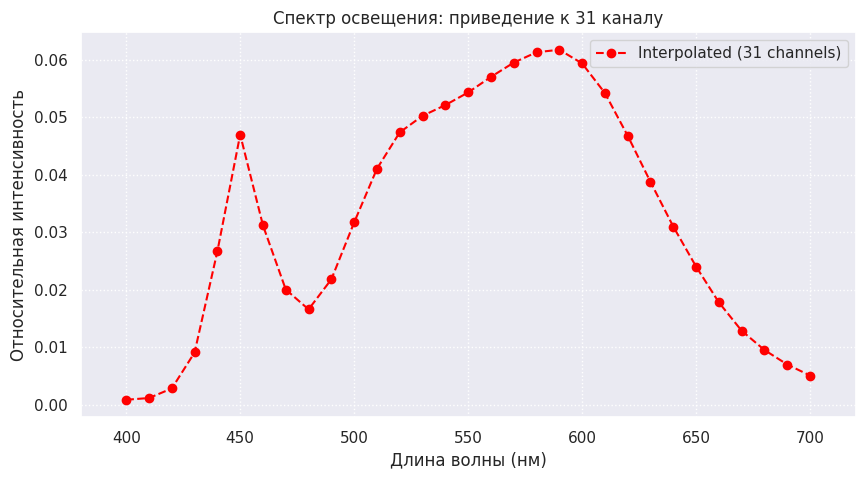

In [48]:
white_img = envi.open('./data/flashlight/083/capture/WHITEREF_083.hdr')
white_data = white_img.load()

dark_img = envi.open('./data/flashlight/083/capture/DARKREF_083.hdr')
dark_data = dark_img.load()

raw_white_spectrum = np.mean(white_data, axis=(0, 1))
raw_dark_spectrum = np.mean(dark_data, axis=(0, 1))

light_spectrum = raw_white_spectrum - raw_dark_spectrum

specim_wls = np.array([float(w) for w in white_img.metadata['wavelength']])

target_wls = np.linspace(400, 700, 31)

interp_func = interp1d(specim_wls, light_spectrum, kind='linear',
                       bounds_error=False, fill_value="extrapolate")

light_spectrum_31 = interp_func(target_wls)

light_spectrum_norm = light_spectrum_31 / light_spectrum_31.sum()

print("Интерполяция завершена. Размерность:", light_spectrum_norm.shape)

# Визуализация для контроля
plt.figure(figsize=(10, 5))
plt.plot(target_wls, light_spectrum_norm,
         'o--', label='Interpolated (31 channels)', color='red')

plt.xlim(380, 720)
plt.title("Спектр освещения: приведение к 31 каналу")
plt.xlabel("Длина волны (нм)")
plt.ylabel("Относительная интенсивность")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

Обучение линейной регрессии на датасете Munsell...
MSE на тестовой выборке Munsell (20%): 0.000448
MSE на РЕАЛЬНЫХ изображениях: 223653.222948


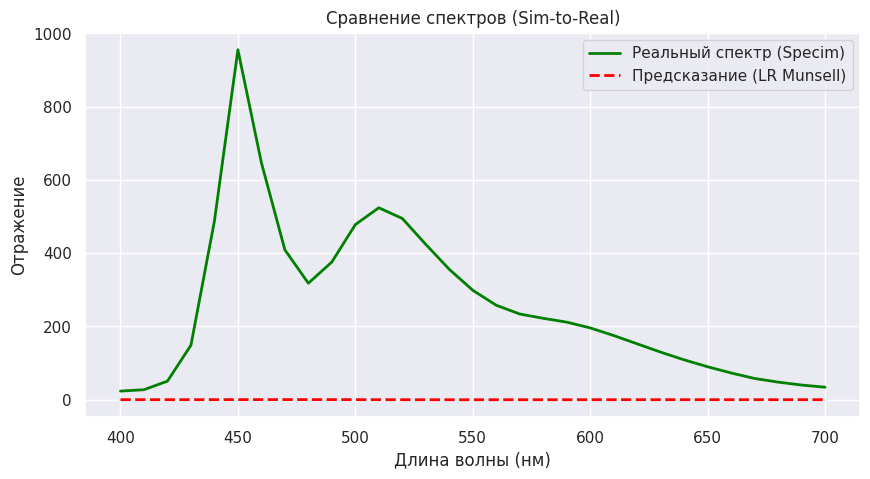

In [49]:
wavelengths_str = "370.000000 373.000000 377.000000 380.000000 383.000000 387.000000 390.000000 393.000000 397.000000 400.000000 403.000000 407.000000 410.000000 413.000000 417.000000 420.000000 423.000000 427.000000 430.000000 433.000000 437.000000 440.000000 443.000000 447.000000 450.000000 453.000000 457.000000 460.000000 463.000000 467.000000 470.000000 473.000000 477.000000 480.000000 483.000000 487.000000 490.000000 493.000000 497.000000 500.000000 503.000000 507.000000 510.000000 513.000000 517.000000 520.000000 523.000000 527.000000 530.000000 533.000000 537.000000 540.000000 543.000000 547.000000 550.000000 553.000000 557.000000 560.000000 563.000000 567.000000 570.000000 573.000000 577.000000 580.000000 583.000000 587.000000 590.000000 593.000000 597.000000 600.000000 603.000000 607.000000 610.000000 613.000000 617.000000 620.000000 623.000000 627.000000 630.000000 633.000000 637.000000 640.000000 643.000000 647.000000 650.000000 653.000000 657.000000 660.000000 663.000000 667.000000 670.000000 673.000000 677.000000 680.000000 683.000000 687.000000 690.000000 693.000000 697.000000 700.000000 703.000000 707.000000 710.000000 713.000000 717.000000 720.000000 723.000000 727.000000 730.000000"
values_str = "0.013979 0.00982097 0.00649137 0.0053779 0.00306603 0.00318108 0.00181273 0.00361689 0.00170022 0.000704909 0.00480284 0.00488461 0.00666502 0.0084493 0.0164837 0.0274815 0.0458242 0.0785095 0.130158 0.204246 0.314031 0.467073 0.683143 1.00655 1.47064 2.03377 2.49899 2.62177 2.3825 2.0281 1.76402 1.58175 1.40909 1.25038 1.13518 1.07648 1.06196 1.06872 1.07378 1.0803 1.09442 1.10739 1.10228 1.0923 1.09413 1.10214 1.09587 1.06673 1.0343 1.01897 1.02444 1.03571 1.03199 1.02317 1.02604 1.03317 1.0297 1.00846 0.982845 0.971082 0.968183 0.966375 0.965639 0.962495 0.954812 0.935454 0.911705 0.894161 0.89661 0.910285 0.91287 0.894728 0.873999 0.864706 0.869985 0.882184 0.882458 0.864757 0.83927 0.813802 0.794647 0.776322 0.757521 0.73873 0.715607 0.690349 0.652257 0.61286 0.579377 0.557233 0.53842 0.523425 0.498968 0.471737 0.445814 0.415325 0.389388 0.371083 0.341187 0.30784 0.286542 0.255436 0.22745 0.207977 0.19008 0.179479 0.174373 0.16649 0.143163"

argyll_wls = np.array([float(x) for x in wavelengths_str.split()])
argyll_vals = np.array([float(x) for x in values_str.split()])

target_wls = np.linspace(400, 700, 31)
interp_func = interp1d(argyll_wls, argyll_vals, kind='linear', bounds_error=False, fill_value="extrapolate")
flash_spectrum = interp_func(target_wls)
flash_spectrum = np.clip(flash_spectrum, 0, None)
flash_spectrum = flash_spectrum / flash_spectrum.sum(axis=0)

total_light_spectrum = light_spectrum_norm + flash_spectrum

def calc_responses(light_spectrum, power_of_light, reflectances, sensor_sensitivities, k=0.25):
    """
    Твоя функция, адаптированная для работы с матрицами NumPy.
    light_spectrum: (31,)
    reflectances: (31, N) - где N это количество образцов Munsell
    sensor_sensitivities: (31, 3) - отклики камеры
    Возвращает: (N, 3) - RGB значения
    """
    radiance = reflectances * light_spectrum[:, np.newaxis]

    responses = power_of_light * k * (sensor_sensitivities.T @ radiance).T
    return np.clip(responses, 0, 1)

munsell = pd.read_csv("data/munsell.csv")
munsell.set_index('wavelength', inplace=True)
munsell = munsell.loc[range(400, 710, 10)]

rgb_ambient = calc_responses(
    light_spectrum=light_spectrum_norm,
    power_of_light=1.0,
    reflectances=munsell,
    sensor_sensitivities=camera_sensor
)

rgb_flash = calc_responses(
    light_spectrum=total_light_spectrum,
    power_of_light=1,
    reflectances=munsell,
    sensor_sensitivities=camera_sensor
)


X_simulated = np.hstack((rgb_ambient, rgb_flash))
Y_simulated = munsell.T

X_train, X_test, Y_train, Y_test = train_test_split(X_simulated, Y_simulated, test_size=0.2, random_state=42)

print("Обучение линейной регрессии на датасете Munsell...")
model = LinearRegression()
model.fit(X_train, Y_train)

Y_pred_munsell = model.predict(X_test)
mse_munsell = mean_squared_error(Y_test, Y_pred_munsell)
print(f"MSE на тестовой выборке Munsell (20%): {mse_munsell:.6f}")


real_df = pd.read_csv("scene_01_dataset.csv")

X_real = real_df.iloc[:, 0:6].values

Y_real_true = real_df.iloc[:, 6:].values

Y_real_pred = model.predict(X_real)

mse_real = mean_squared_error(Y_real_true, Y_real_pred)
print(f"MSE на РЕАЛЬНЫХ изображениях: {mse_real:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(target_wls, Y_real_true[0], label="Реальный спектр (Specim)", color='green', linewidth=2)
plt.plot(target_wls, Y_real_pred[0], label="Предсказание (LR Munsell)", color='red', linestyle='--', linewidth=2)
plt.title("Сравнение спектров (Sim-to-Real)")
plt.xlabel("Длина волны (нм)")
plt.ylabel("Отражение")
plt.legend()
plt.grid(True)
plt.show()

In [50]:
X_simulated

array([[0.38332727, 1.        , 0.27209548, 0.66838681, 1.        ,
        0.68982289],
       [0.28795324, 0.82051165, 0.20052316, 0.50173649, 1.        ,
        0.50741615],
       [0.21481811, 0.60257342, 0.14513704, 0.37414491, 1.        ,
        0.36717086],
       ...,
       [0.12311578, 0.19879209, 0.03690894, 0.22837929, 0.36758511,
        0.09131564],
       [0.20712439, 0.33691722, 0.05995596, 0.3751594 , 0.61207674,
        0.14887764],
       [0.12979548, 0.19846666, 0.03546739, 0.23970158, 0.36549885,
        0.08734786]], shape=(1269, 6))

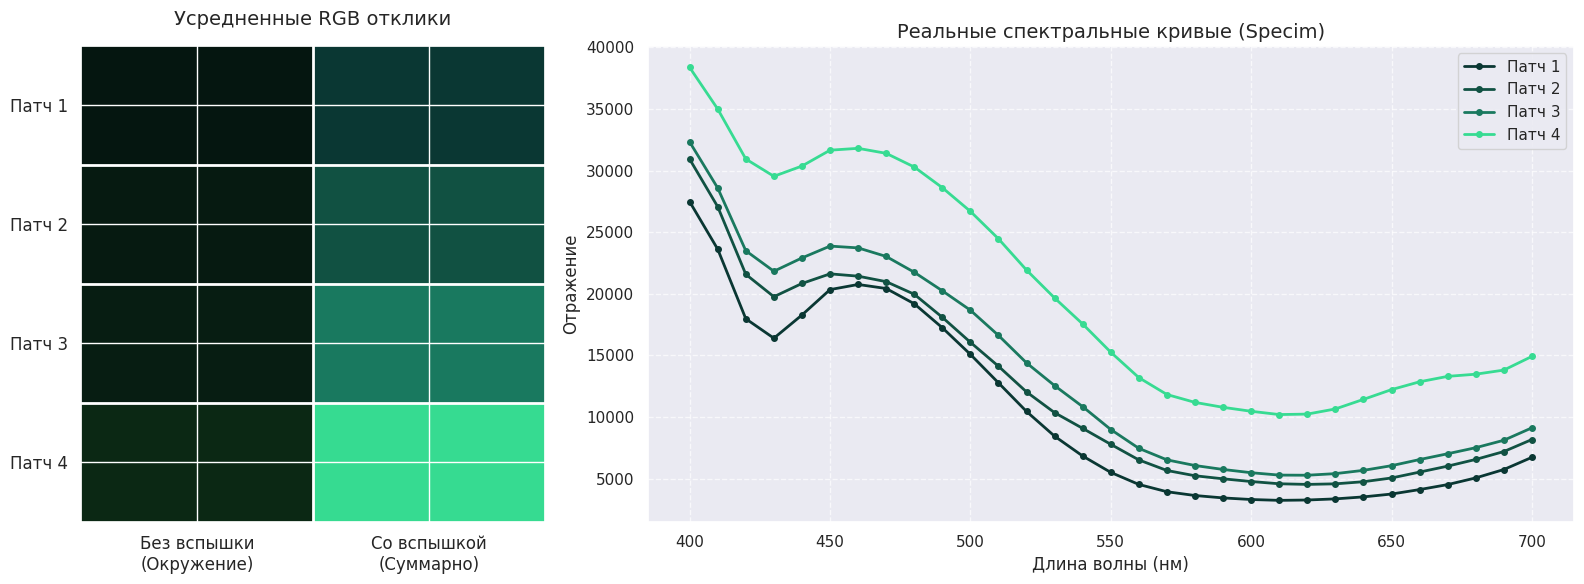

In [55]:

df = pd.read_csv("scene_01_dataset.csv")
num_patches = len(df)

rgb_no_flash = df[['R', 'G', 'B']].values
rgb_flash = df[['R_flash', 'G_flash', 'B_flash']].values

spectra = df.iloc[:, 6:].values
wavelengths = np.linspace(400, 700, 31)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 2]})

color_grid = np.zeros((num_patches, 2, 3))
color_grid[:, 0, :] = rgb_no_flash
color_grid[:, 1, :] = rgb_flash

if color_grid.max() > 1.5:
    color_grid = color_grid / 255.0
color_grid = np.clip(color_grid, 0, 1)

axes[0].imshow(color_grid, aspect='auto')

# Оформляем оси для квадратиков
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Без вспышки\n(Окружение)', 'Со вспышкой\n(Суммарно)'], fontsize=12)
axes[0].set_yticks(range(num_patches))
axes[0].set_yticklabels([f'Патч {i+1}' for i in range(num_patches)], fontsize=12)
axes[0].set_title("Усредненные RGB отклики", fontsize=14, pad=15)

# Рисуем белые линии-разделители для красоты
for i in range(num_patches - 1):
    axes[0].axhline(i + 0.5, color='white', linewidth=2)
axes[0].axvline(0.5, color='white', linewidth=2)


for i in range(num_patches):
    line_color = color_grid[i, 1, :]
    axes[1].plot(wavelengths, spectra[i] / light_spectrum_norm, marker='o', markersize=4, linewidth=2,
                 color=line_color, label=f'Патч {i+1}')

axes[1].set_title("Реальные спектральные кривые (Specim)", fontsize=14)
axes[1].set_xlabel("Длина волны (нм)", fontsize=12)
axes[1].set_ylabel("Отражение", fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

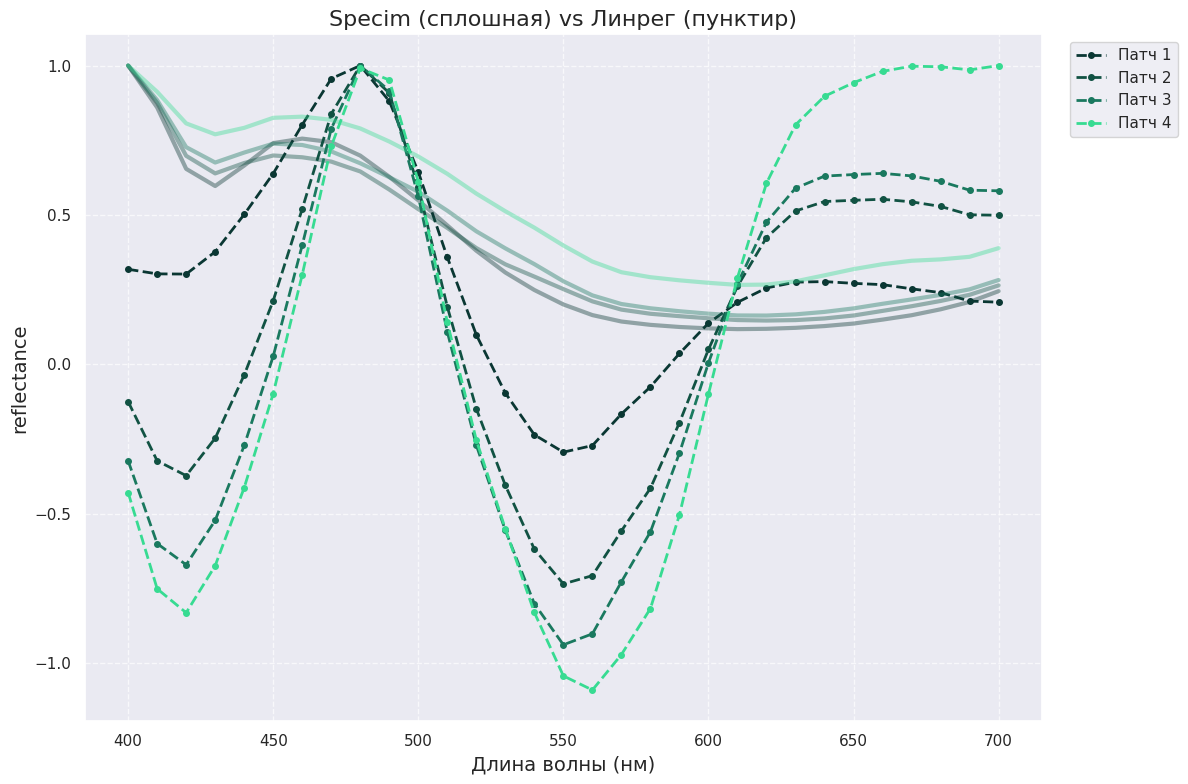

MSE формы спектров (без учета яркости): 0.451388


In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme("notebook")

num_patches = len(Y_real_true)

Y_true_shape = Y_real_true / np.max(Y_real_true, axis=1, keepdims=True)
Y_pred_shape = Y_real_pred / np.max(Y_real_pred, axis=1, keepdims=True)


fig, ax = plt.subplots(figsize=(12, 8))

for i in range(num_patches):
    line_color = color_grid[i, 1, :]

    Y_new_true = Y_true_shape[i] / light_spectrum_norm
    Y_new_true = Y_new_true / Y_new_true.max()
    ax.plot(wavelengths, Y_new_true, linewidth=3, color=line_color, alpha=0.4)

    ax.plot(wavelengths, Y_pred_shape[i], marker='o', markersize=4, linewidth=2,
            color=line_color, linestyle='--', label=f'Патч {i+1}' if i < 10 else "")

ax.set_title("Specim (сплошная) vs Линрег (пунктир)", fontsize=16)
ax.set_xlabel("Длина волны (нм)", fontsize=14)
ax.set_ylabel("reflectance", fontsize=14)

if num_patches <= 24:
    ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

from sklearn.metrics import mean_squared_error

# Считаем MSE только по форме
mse_shape = mean_squared_error(Y_true_shape, Y_pred_shape)
print(f"MSE формы спектров (без учета яркости): {mse_shape:.6f}")

In [9]:
raw_noflash = RawImage.from_file(Path("data/flashlight/5.dng"))

img_noflash = get_image(raw_noflash)
img_noflash = img_noflash.astype(np.float32)

In [10]:
raw_flash = RawImage.from_file(Path("data/flashlight/5_flash.dng"))

img_flash = get_image(raw_flash)
img_flash = img_flash.astype(np.float32)

In [13]:
%matplotlib tk
import matplotlib.pyplot as plt

plt.imshow(img_flash_srgb)
print("Кликни 4 точки и нажми Enter")
pts = plt.ginput(12, timeout=0)
plt.close()
print(pts)

Кликни 4 точки и нажми Enter
[(np.float64(6142.300117176056), np.float64(3366.571184454643)), (np.float64(5917.322087686748), np.float64(2976.6092666731765)), (np.float64(4887.422663802362), np.float64(2321.67322527097)), (np.float64(4437.466604823746), np.float64(2351.670295869544)), (np.float64(3997.5095693779904), np.float64(2396.6659017674056)), (np.float64(3542.553998632945), np.float64(2386.6668782345478)), (np.float64(3137.5935455521912), np.float64(2411.6644370666927)), (np.float64(3247.5828044136306), np.float64(3206.5868079289135)), (np.float64(3662.542281027242), np.float64(3201.587296162484)), (np.float64(4042.505175275851), np.float64(3191.5882726296263)), (np.float64(4447.465628356605), np.float64(3181.589249096768)), (np.float64(4892.422175568791), np.float64(3171.59022556391))]


In [11]:
cube_raw, specim_wls = load_reflectance_from_results("./data/flashlight/085")
cube_31, wls_31 = interpolate_cube_to_31(cube_raw, specim_wls)

approx_rgb = get_approx_rgb(cube_31, wls_31)

In [14]:
def collect_points_opencv(image, title="rocket science", window_width=1200, window_height=800):
    if image.dtype == np.float32 or image.dtype == np.float64:
        img_disp = (np.clip(image, 0, 1) * 255).astype(np.uint8)
    else:
        img_disp = image.copy()

    img_disp = cv2.cvtColor(img_disp, cv2.COLOR_RGB2BGR)
    points = []

    def mouse_callback(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            points.append((x, y))
            cv2.circle(img_disp, (x, y), radius=15, color=(0, 255, 0), thickness=-1)
            cv2.imshow(title, img_disp)

    cv2.namedWindow(title, cv2.WINDOW_NORMAL)

    cv2.resizeWindow(title, window_width, window_height)

    cv2.setMouseCallback(title, mouse_callback)
    cv2.imshow(title, img_disp)

    cv2.waitKey(0)
    cv2.destroyAllWindows()
    return points

pts_base = collect_points_opencv(img_noflash)
print("Результат:", pts_base)

QObject::moveToThread: Current thread (0x44071430) is not the object's thread (0x43216b30).
Cannot move to target thread (0x44071430)

QObject::moveToThread: Current thread (0x44071430) is not the object's thread (0x43216b30).
Cannot move to target thread (0x44071430)

QObject::moveToThread: Current thread (0x44071430) is not the object's thread (0x43216b30).
Cannot move to target thread (0x44071430)

QObject::moveToThread: Current thread (0x44071430) is not the object's thread (0x43216b30).
Cannot move to target thread (0x44071430)

QObject::moveToThread: Current thread (0x44071430) is not the object's thread (0x43216b30).
Cannot move to target thread (0x44071430)

QObject::moveToThread: Current thread (0x44071430) is not the object's thread (0x43216b30).
Cannot move to target thread (0x44071430)

QObject::moveToThread: Current thread (0x44071430) is not the object's thread (0x43216b30).
Cannot move to target thread (0x44071430)

QObject::moveToThread: Current thread (0x44071430) is n

Результат: [(6170, 3428), (5963, 3030), (4920, 2359), (4464, 2384), (4025, 2401), (3594, 2417), (3164, 2442), (3520, 1308), (3280, 3237), (3677, 3221), (4091, 3212), (4497, 3196), (4928, 3196)]


In [ ]:
# 084


In [16]:
# 085
pts_sp = [(486, 349), (464, 291), (309, 194), (243, 195), (180, 198), (116, 201), (55, 202), (109, 39), (71, 323), (131, 322), (192, 321), (249, 320), (311, 318)]
pts_noflash = [(6170, 3428), (5963, 3030), (4920, 2359), (4464, 2384), (4025, 2401), (3594, 2417), (3164, 2442), (3520, 1308), (3280, 3237), (3677, 3221), (4091, 3212), (4497, 3196), (4928, 3196)]
pts_flash = [(6137, 3394), (5922, 3005), (4887, 2343), (4439, 2368), (4000, 2393), (3570, 2409), (3147, 2426), (3495, 1308), (3255, 3212), (3652, 3229), (4067, 3204), (4472, 3196), (4895, 3179)]

In [17]:
import cv2
import numpy as np

def align_and_crop(img_base, img_to_align, pts_base, pts_to_align):
    """
    Выравнивает img_to_align по точкам относительно img_base.
    """
    pts_base = np.array(pts_base, dtype=np.float32)
    pts_to_align = np.array(pts_to_align, dtype=np.float32)

    h_matrix, _ = cv2.findHomography(pts_to_align, pts_base)

    height, width = img_base.shape[:2]

    aligned_img = cv2.warpPerspective(img_to_align, h_matrix, (width, height))

    return aligned_img

aligned_noflash = align_and_crop(cube_31, img_noflash, pts_sp, pts_noflash)
aligned_flash = align_and_crop(cube_31, img_flash, pts_sp, pts_flash)

In [23]:
import cv2
import numpy as np
import pandas as pd

collected_data = []
window_size = 5
hw = window_size // 2

def collect_data_opencv(aligned_noflash, aligned_flash, cube_31, wls_31):
    global collected_data
    collected_data = []

    display_rgb = get_approx_rgb(cube_31, wls_31)

    if display_rgb.dtype == np.float32 or display_rgb.dtype == np.float64:
        display_bgr = (np.clip(display_rgb, 0, 1) * 255).astype(np.uint8)
    else:
        display_bgr = display_rgb.copy()

    display_bgr = cv2.cvtColor(display_bgr, cv2.COLOR_RGB2BGR)
    img_disp = display_bgr.copy()

    H, W = cube_31.shape[:2]
    window_title = "Data Collector"

    def mouse_callback(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            patch_no = aligned_noflash[y-hw:y+hw+1, x-hw:x+hw+1]
            patch_fl = aligned_flash[y-hw:y+hw+1, x-hw:x+hw+1]
            patch_sp = cube_31[y-hw:y+hw+1, x-hw:x+hw+1]

            mean_no = np.mean(patch_no, axis=(0,1))
            mean_fl = np.mean(patch_fl, axis=(0,1))
            mean_sp = np.mean(patch_sp, axis=(0,1))

            row = np.concatenate([[x, y], mean_no, mean_fl, mean_sp])
            collected_data.append(row)

            cv2.circle(img_disp, (x, y), radius=3, color=(0, 255, 0), thickness=-1)
            cv2.imshow(window_title, img_disp)

            print(f"Точка ({x}, {y}) добавлена")


    cv2.namedWindow(window_title, cv2.WINDOW_NORMAL)

    cv2.resizeWindow(window_title, 1200, 800)

    cv2.setMouseCallback(window_title, mouse_callback)
    cv2.imshow(window_title, img_disp)

    cv2.waitKey(0)
    cv2.destroyAllWindows()

collect_data_opencv(aligned_noflash, aligned_flash, cube_31, wls_31)

columns = ['x', 'y', 'R', 'G', 'B', 'R_flash', 'G_flash', 'B_flash'] + [f'{int(w)}' for w in wls_31]
df_final = pd.DataFrame(collected_data, columns=columns)

df_final[['x', 'y']] = df_final[['x', 'y']].astype(int)

df_final.to_csv("my_collected_dataset_084.csv", index=False)
print(f"\nГотово! Успешно сохранено {len(df_final)} строк в файл my_collected_dataset.csv")

QObject::moveToThread: Current thread (0x44071430) is not the object's thread (0x43216b30).
Cannot move to target thread (0x44071430)

QObject::moveToThread: Current thread (0x44071430) is not the object's thread (0x43216b30).
Cannot move to target thread (0x44071430)

QObject::moveToThread: Current thread (0x44071430) is not the object's thread (0x43216b30).
Cannot move to target thread (0x44071430)

QObject::moveToThread: Current thread (0x44071430) is not the object's thread (0x43216b30).
Cannot move to target thread (0x44071430)

QObject::moveToThread: Current thread (0x44071430) is not the object's thread (0x43216b30).
Cannot move to target thread (0x44071430)

QObject::moveToThread: Current thread (0x44071430) is not the object's thread (0x43216b30).
Cannot move to target thread (0x44071430)

QObject::moveToThread: Current thread (0x44071430) is not the object's thread (0x43216b30).
Cannot move to target thread (0x44071430)

QObject::moveToThread: Current thread (0x44071430) is n

Точка (347, 284) добавлена
Точка (278, 283) добавлена
Точка (219, 286) добавлена
Точка (158, 287) добавлена
Точка (97, 289) добавлена
Точка (37, 291) добавлена

Готово! Успешно сохранено 6 строк в файл my_collected_dataset.csv
